# **Superstore Sales & Profitability Analysis**

**Author:** Nuria Benítez | **Tools:** Python (pandas, numpy, matplotlib, seaborn, scipy) | **Dataset:** Superstore Sample from Kaggle


## Business Context

The dataset contains around 10,000 order lines from a US retail superstore (2014-2017), covering sales, discounts, profit, shipping and customer information across three product categories (Furniture, Office Supplies, Technology) and four US regions (Central, East, South, West).


## Business Questions
This notebook investigates the following questions:

1. **Discounting strategy**.
- How much discount can the business afford to give?
- At what discount level does profitability break down?
- Does this threshold depend on the product's price tier?
- Which subcategories can safely sustain deep discounts?


2. **Time trends**.
- Is the business growing in a healthy and stable way?
- Is there a recurring seasonal pattern (strong/weak months)?
- Is there a decline driven by a category, discounting or customer churn?
- Does the trend vary by region?


3. **Regional performance**.
- Which regions are the most profitable and the most at risk?
- Does any region show a structural or recurring loss in a specific category?
- Are there operational factors that compound a region's financial risk?


4. **Customer value**.
- Where does profitability really come from?
- Are there customers who generate large sales volumes but negative profit?
- Does a recency/frequency/monetary (RFM) segmentation reveal customer segments?


5. **Order-level economics**.
- How should individual order profitability be read?
- How should profit margin (%) be interpreted alongside absolute profit ($) at the order level?
- Do small orders systematically look worse in margin terms than large ones?
- Which products or orders are the best candidates for a pricing or discount review?

A consolidated **Executive Summary** with the key findings and business recommendations is provided at the end of the notebook.

## Contents
1. [Data Loading](#data-loading)
2. [Data Quality Checks & Cleaning](#data-quality)
3. [Feature Engineering](#feature-engineering)
4. [Discount vs. Profit Relationship](#discount-profit)
5. [Timeline Analysis](#timeline)
6. [Region Analysis](#region)
7. [Customer Analysis (Concentration, Pareto, RFM)](#customer)
8. [Discount Policy & Structural Loss by Price Tier](#discount-policy)
9. [Order-Level Profitability](#order-level)
10. [Executive Summary & Business Recommendations](#executive-summary)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

<a name="data-loading"></a>
## 1. Data Loading & Initial Overview

In [ ]:
df = pd.read_excel('superstore_sample.xlsx')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9988 non-null   float64
 18  Quantity

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.00,0.00,41.91
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.00,0.00,219.58
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.00,0.00,6.87
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5.00,0.45,-383.03
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2.00,0.20,2.52


<a name="data-quality"></a>
## 2. Data Quality Checks & Cleaning

### 2.1 Duplicate Records

In [ ]:
cols_no_row_id = df.columns.difference(['Row ID'])
duplicated = df.duplicated(subset=cols_no_row_id).sum()
print(f"Number of fully duplicated rows: {duplicated}")

# Inspect the duplicated orders
df[df.duplicated(subset=cols_no_row_id, keep=False)].sort_values('Order ID')

Number of fully duplicated rows: 2


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3405,3406,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.37,2.00,0.30,-12.06
3406,3407,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.37,2.00,0.30,-12.06
430,431,US-2016-123750,4/15/2016,4/21/2016,Standard Class,RB-19795,Ross Baird,Home Office,United States,Gastonia,...,28052,South,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,NaN,NaN,NaN,NaN
431,432,US-2016-123750,4/15/2016,4/21/2016,Standard Class,RB-19795,Ross Baird,Home Office,United States,Gastonia,...,28052,South,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,NaN,NaN,NaN,NaN


In [ ]:
# Remove the fully duplicated rows
df1 = df[(df['Row ID'] != 3406) & (df['Row ID'] != 431)]

### 2.2. Suspicious Near-Duplicate Lines

In [ ]:
suspicious_orders = df1[df1.duplicated(subset=['Order ID', 'Product ID'], keep=False)] \
    .sort_values(['Order ID', 'Product ID'])

# Check whether Quantity, Discount or Sales differ between the "duplicated" lines
suspicious_orders[['Order ID', 'Product ID', 'Quantity', 'Discount', 'Sales', 'Profit']]

,Order ID,Product ID,Quantity,Discount,Sales,Profit
6498,CA-2015-103135,OFF-BI-10000069,9.00,0.00,135.09,62.14
6500,CA-2015-103135,OFF-BI-10000069,6.00,0.00,90.06,41.43
350,CA-2016-129714,OFF-PA-10001970,2.00,0.00,24.56,11.54
352,CA-2016-129714,OFF-PA-10001970,4.00,0.00,49.12,23.09
1300,CA-2016-137043,FUR-FU-10003664,6.00,0.00,572.76,166.10
1301,CA-2016-137043,FUR-FU-10003664,3.00,0.00,286.38,83.05
9168,CA-2016-140571,OFF-PA-10001954,14.00,0.00,319.76,147.09
9169,CA-2016-140571,OFF-PA-10001954,2.00,0.00,45.68,21.01
7881,CA-2017-118017,TEC-AC-10002006,6.00,0.20,76.75,10.55
7882,CA-2017-118017,TEC-AC-10002006,8.00,0.20,102.34,14.07


Same product recorded twice within the same order, but with different quantities. These are treated as separate purchase lines rather than duplicates, since quantity, sales and profit differ between them. Thus, consistent with two distinct add-to-cart events for the same product.

### 2.3. Missing Values

In [ ]:
missing_values = df1.isna().sum()
print(f'Missing values per variable:\n{missing_values}')

Missing values per variable:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            5
Quantity         5
Discount         5
Profit           5
dtype: int64


In [ ]:
nan_rows = df1[df1[['Sales', 'Quantity', 'Discount', 'Profit']].isnull().any(axis=1)]
print(nan_rows['Product ID'].value_counts())
print(f"Unique products affected: {nan_rows['Product ID'].nunique()}")

# Are there other, complete records for this same product?
df1[df1['Product ID'] == 'TEC-AC-10004659']

Product ID
TEC-AC-10004659    5
Name: count, dtype: int64
Unique products affected: 1


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
181,182,CA-2014-166191,2014-05-12 00:00:00,2014-09-12 00:00:00,Second Class,DK-13150,David Kendrick,Corporate,United States,Decatur,...,62521,Central,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,NaN,NaN,NaN,NaN
431,432,US-2016-123750,4/15/2016,4/21/2016,Standard Class,RB-19795,Ross Baird,Home Office,United States,Gastonia,...,28052,South,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,NaN,NaN,NaN,NaN
1406,1407,US-2014-118486,2014-06-04 00:00:00,2014-08-04 00:00:00,First Class,SD-20485,Shirley Daniels,Home Office,United States,Philadelphia,...,19143,East,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,NaN,NaN,NaN,NaN
1969,1970,CA-2017-117485,9/23/2017,9/29/2017,Standard Class,BD-11320,Bill Donatelli,Consumer,United States,Tulsa,...,74133,Central,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,NaN,NaN,NaN,NaN
1971,1972,CA-2017-140242,2017-06-05 00:00:00,2017-11-05 00:00:00,Standard Class,ML-17755,Max Ludwig,Home Office,United States,Chicago,...,60623,Central,TEC-AC-10004659,Technology,Accessories,Imation Secure+ Hardware Encrypted USB 2.0 Fla...,NaN,NaN,NaN,NaN


A missing-value check on the numeric columns (Sales, Quantity, Discount, Profit) revealed 5 rows with null values, all associated with a single product (TEC-AC-10004659, Imation Secure+ USB drive), which has no other complete records to impute from. Imputing with dataset-wide averages was considered and rejected, since doing so would fabricate financial figures for a specific product without any basis in its actual sales history.
Given the negligible volume (5 out of 9,987 records = <0.1% of the dataset) and the absence of a defensible imputation strategy, these rows were dropped.

In [ ]:
df1 = df1.dropna(subset=['Sales', 'Quantity', 'Discount', 'Profit'])

### 2.4. Descriptive Statistics & Outlier Detection

In [ ]:
df1[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,"9,987.00","9,987.00","9,987.00","9,987.00"
mean,229.80,3.79,0.16,28.64
std,623.45,2.23,0.21,234.34
min,0.44,1.00,0.00,"-6,599.98"
25%,17.25,2.00,0.00,1.73
50%,54.37,3.00,0.20,8.64
75%,209.84,5.00,0.20,29.34
max,"22,638.48",14.00,0.80,"8,399.98"


- A wide spread across sale values which means a catalogue that spans a broad price range.
- 25% of order lines total less than $18.

- The average order line involves approximately 3 units.

- The maximum discount applied is 80%.

- The median order line profit is under $8.

In [ ]:
# Largest single loss in the dataset, driven by a high discount
df1.loc[df1['Profit'].idxmin(), 'Discount']

np.float64(0.7)

In [ ]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers | bounds [{lower_bound:.2f}, {upper_bound:.2f}]")
    return outliers

outliers_sales = detect_outliers_iqr(df1, 'Sales')
outliers_quantity = detect_outliers_iqr(df1, 'Quantity')
outliers_discount = detect_outliers_iqr(df1, 'Discount')
outliers_profit = detect_outliers_iqr(df1, 'Profit')

Sales: 1167 outliers | bounds [-271.63, 498.72]
Quantity: 170 outliers | bounds [-2.50, 9.50]
Discount: 856 outliers | bounds [-0.30, 0.50]
Profit: 1877 outliers | bounds [-39.69, 70.76]


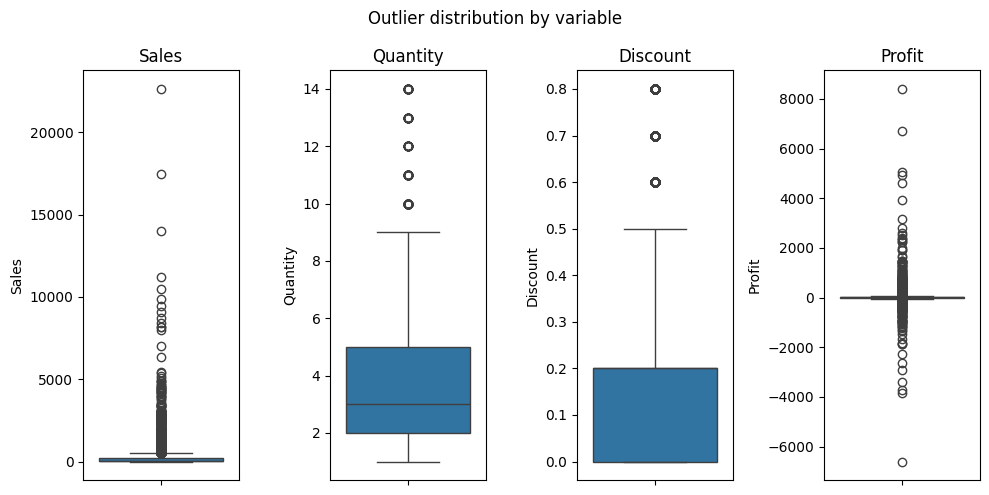

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))

cols = ['Sales', 'Quantity', 'Discount', 'Profit']
for ax, col in zip(axes, cols):
    sns.boxplot(y=df1[col], ax=ax)
    ax.set_title(col)

plt.suptitle('Outlier distribution by variable')
plt.tight_layout()
plt.show()

All four variables show heavy right skewness and a large number of outliers under the IQR rule. However, the nature of these outliers differs.

On the one hand, sales and profit have long tails driven by a handful of big value orders (up to $22,000 and 8,000 respectively). These are legitimate large transactions, not data errors, and removing them would strip out exactly the orders that matter most to revenue.
On the other hand, outliers in quantity simply reflect bulk purchases.
Finally, outliers in discount (60-80%) worth flagging as they cause huge impact on the company's revenue.


### 2.5. Logical Validations

In [ ]:
print("Rows with Sales <= 0:", (df1['Sales'] <= 0).sum())
print("Rows with Quantity <= 0:", (df1['Quantity'] <= 0).sum())
print("Rows with Discount outside [0, 1]:", df1[(df1['Discount'] < 0) | (df1['Discount'] > 1)].shape[0])

Rows with Sales <= 0: 0
Rows with Quantity <= 0: 0
Rows with Discount outside [0, 1]: 0


In [ ]:
# Each postal code should map to exactly one city and one state
print(df1.groupby('Postal Code')['City'].nunique().sort_values(ascending=False).value_counts())
print(df1.groupby('Postal Code')['State'].nunique().sort_values(ascending=False).value_counts())

City
1    630
2      1
Name: count, dtype: int64
State
1    631
Name: count, dtype: int64


In [ ]:
postal_multi_city = df1.groupby('Postal Code')['City'].nunique()
postal_multi_city = postal_multi_city[postal_multi_city > 1]
print(postal_multi_city)

df1[df1['Postal Code'].isin(postal_multi_city.index)][['Postal Code', 'City', 'State']].drop_duplicates()

Postal Code
92024    2
Name: City, dtype: int64


,Postal Code,City,State
481,92024,San Diego,California
1113,92024,Encinitas,California


One postal code (92024) is associated with two different city names in the dataset: San Diego and Encinitas, both in California. It might be a data entry inconsistency rather than a real geographic anomaly. There is no need for a correction as the data of the records provide reliable information.

<a name="feature-engineering"></a>
## 3. Feature Engineering

In [ ]:
df1['Order Date'] = pd.to_datetime(df1['Order Date'], format='mixed', errors='coerce')
df1['Ship Date'] = pd.to_datetime(df1['Ship Date'], format='mixed', errors='coerce')
df1['Order Year'] = df1['Order Date'].dt.year
df1['Order Month'] = df1['Order Date'].dt.month
df1['Order Day of Week'] = df1['Order Date'].dt.day_name()
df1['Order Quarter'] = df1['Order Date'].dt.quarter
df1['Shipping_Time'] = (df1['Ship Date'] - df1['Order Date']).dt.days
df1['Profit Margin'] = df1['Profit'] / df1['Sales']

<a name="discount-profit"></a>
## 4. Discount vs. Profit Relationship

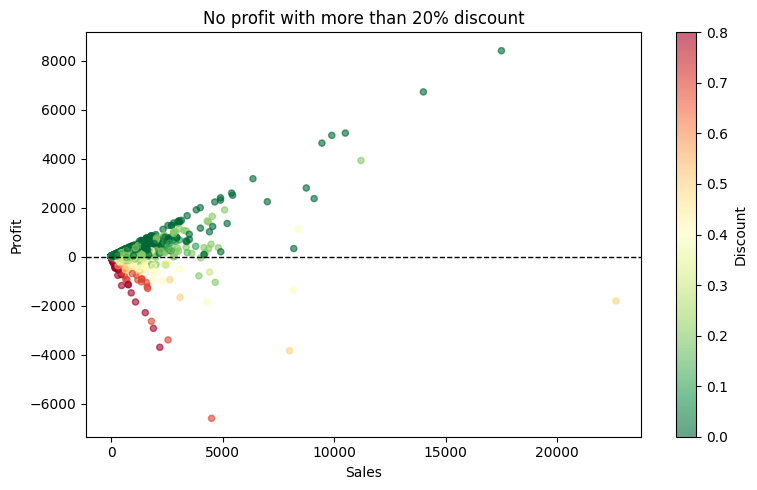

In [ ]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df1['Sales'], df1['Profit'], c=df1['Discount'],
                       cmap='RdYlGn_r', alpha=0.6, s=20)
plt.colorbar(scatter, label='Discount')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('No profit with more than 20% discount')
plt.tight_layout()
plt.show()

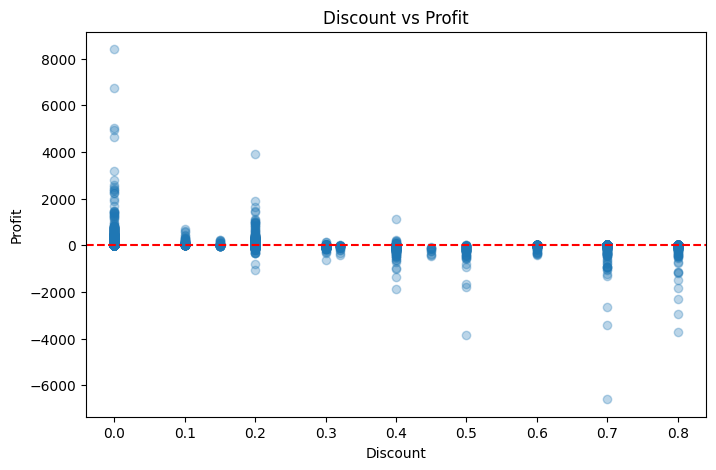

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df1['Discount'], df1['Profit'], alpha=0.3)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.axhline(0, color='red', linestyle='--')
plt.show()

**Discount vs. Profit: the 20% threshold.**

The relationship is not linear: it is a threshold effect.
Discounts up to 20% rarely hurt profitability; most transactions in this range remain profitable, with some of the highest profit values occurring at 0% discount.


Beyond 30%, the pattern shifts sharply: profit turns negative in nearly all cases, and losses grow larger as the discount rate increases, reaching their most severe values (down to -$6,000+) at 70-80% discount.


A simple correlation coefficient masks this pattern because it assumes a gradual, linear effect rather than a sudden break past a specific point. Business implication in the Executive Summary.

### 4.1 Statistical Validation: Is the 20% Threshold Real?

A Welch's t-test compares average profit margin between low-discount orders (≤20%) and high-discount orders (>30%). Checking whether the gap visible in the scatter plot above reflects a genuine difference in means, or could plausibly be sampling noise. Welch's version is used instead of a standard t-test because the two groups don't have equal variance, margin swings far more wildly at high discount levels, as the scatter plot already suggests.

In [ ]:
low_discount = df1.loc[df1['Discount'] <= 0.20, 'Profit Margin']
high_discount = df1.loc[df1['Discount'] > 0.30, 'Profit Margin']

t_stat, p_value = stats.ttest_ind(low_discount, high_discount, equal_var=False)
print(f"Welch's t-test: t = {t_stat:.2f}, p-value {'< 0.001' if p_value < 0.001 else f'= {p_value:.4g}'}")
print(f"Mean margin, discount <=20%: {low_discount.mean():.1%}")
print(f"Mean margin, discount  >30%: {high_discount.mean():.1%}")

Welch's t-test: t = 63.04, p-value < 0.001
Mean margin, discount <=20%: 26.7%
Mean margin, discount  >30%: -91.5%


Welch's t-test confirms this is not sampling noise: average profit margin is +26.7% on orders discounted ≤20%, against -91.5% above 30%. At this sample size (10,000 rows), a low p-value is expected almost regardless of effect size, what matters here is the magnitude of the swing itself, from clearly profitable to a loss that nearly doubles the order's own sales value.

<a name="timeline"></a>
## 5. Timeline Analysis

In [ ]:
# Profit grows year over year overall
df1.groupby('Order Year')['Profit'].sum()

,Profit
Order Year,
2014,"49,457.50"
2015,"61,618.60"
2016,"81,663.79"
2017,"93,260.44"


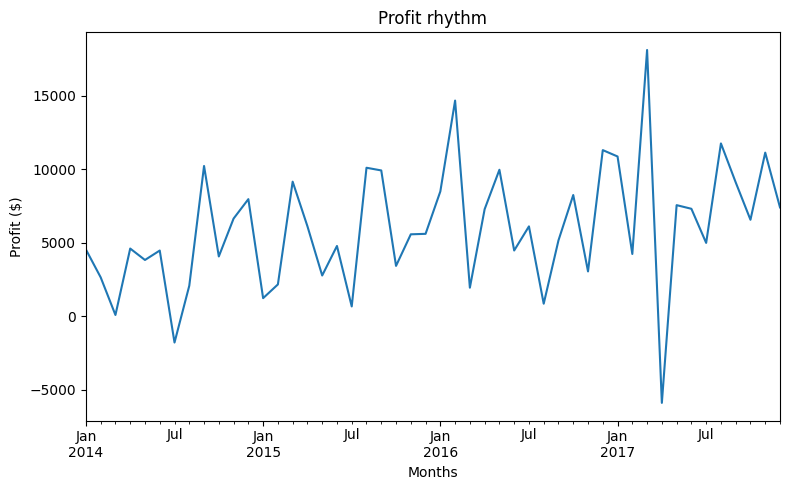

In [ ]:
plt.figure(figsize=(8,5))
df1.groupby([df1['Order Date'].dt.to_period('M')])['Profit'].sum().plot(
    title='Profit rhythm', ylabel='Profit ($)', xlabel = 'Months')
plt.tight_layout()
plt.show()

No single seasonal pattern dominates the whole series, but July is consistently a slow month and September tends to rebound after summer. 2017 recorded both the highest overall profit and its sharpest monthly drop, in April. It is investigated below.

Is the April 2017 decline concentrated in a specific region or category?

<Figure size 800x500 with 0 Axes>

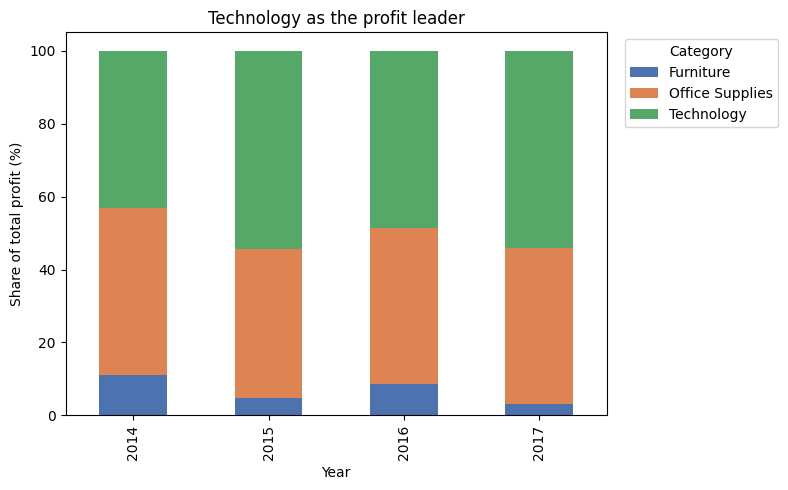

Profit percentage change by category:


Category,Furniture,Office Supplies,Technology
Order Year,,,
2015,-44.88,11.09,56.60
2016,130.83,39.69,18.32
2017,-56.63,13.33,27.40


In [ ]:
# Profit by year and category
profit_cat_year = df1.groupby(['Order Year', 'Category'])['Profit'].sum().unstack()

## Representation
plt.figure(figsize=(8,5))
profit_cat_year_share = profit_cat_year.div(profit_cat_year.sum(axis=1), axis=0) * 100

profit_cat_year_share.plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color=['#4C72B0', '#DD8452', '#55A868']
)

plt.ylabel('Share of total profit (%)')
plt.xlabel('Year')
plt.title('Technology as the profit leader')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Year-over-year change by category (%)
profit_cat_year_pct =(profit_cat_year.pct_change() * 100)
print('Profit percentage change by category:')
profit_cat_year_pct.dropna(how='all')

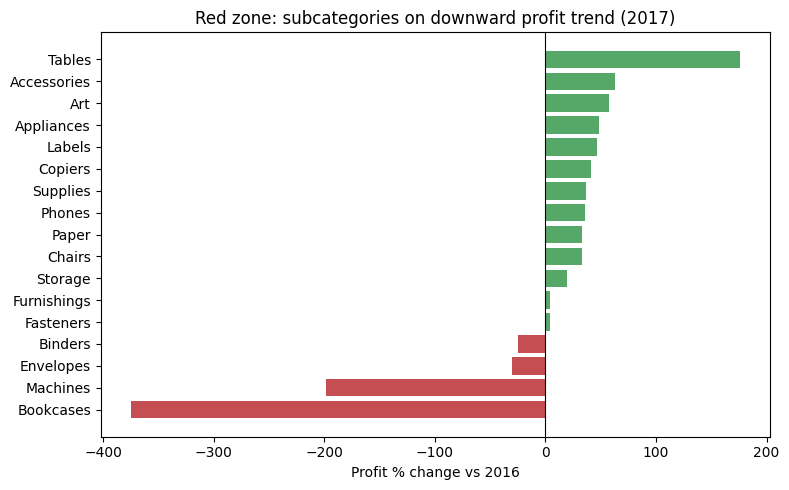

In [ ]:
profit_subcat_year = df1.groupby(['Order Year', 'Sub-Category'])['Profit'].sum().unstack()
profit_subcat_year_pct = profit_subcat_year.pct_change() * 100

# Sort the most recent year to see which sub-categories dropped the most
last_year = profit_subcat_year_pct.index.max()
data = profit_subcat_year_pct.loc[last_year].sort_values()

colors = ['#C44E52' if v < 0 else '#55A868' for v in data]

plt.figure(figsize=(8, 5))
plt.barh(data.index, data.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(f'Profit % change vs {last_year - 1}')
plt.title(f'Red zone: subcategories on downward profit trend ({last_year})')
plt.tight_layout()
plt.show()

In [ ]:
discount_profit_cat = df1.groupby(['Order Year', 'Category']).agg(
    avg_discount=('Discount', 'mean'),
    total_profit=('Profit', 'sum')
).reset_index()

# Compare only the last two years
last_two_years = sorted(df1['Order Year'].unique())[-2:]

# No change in furniture annual discount
def highlight_furniture_discount(row):
    styles = [''] * len(row)
    if row['Category'] == 'Furniture':
        idx = row.index.get_loc('avg_discount')
        styles[idx] = 'background-color: #f4cccc; font-weight: bold'
    return styles

discount_profit_cat[discount_profit_cat['Order Year'].isin(last_two_years)] \
    .style.format({'avg_discount': '{:.1%}', 'total_profit': '${:,.0f}'}) \
    .apply(highlight_furniture_discount, axis=1)

,Order Year,Category,avg_discount,total_profit
6,2016,Furniture,17.7%,"$6,960"
7,2016,Office Supplies,15.2%,"$35,061"
8,2016,Technology,13.6%,"$39,643"
9,2017,Furniture,17.0%,"$3,018"
10,2017,Office Supplies,16.0%,"$39,737"
11,2017,Technology,13.0%,"$50,505"


In [ ]:
# By region
profit_region_year = df1.groupby(['Order Year', 'Region'])['Profit'].sum().unstack()
profit_region_year_pct = profit_region_year.pct_change() * 100
profit_region_year_pct.dropna(how='all').style.format('{:.1f}%').background_gradient(cmap='RdYlGn', vmin=-100, vmax=100, axis=None)

Region,Central,East,South,West
Order Year,,,,
2015,2431.1%,23.7%,-30.0%,2.1%
2016,69.8%,-4.5%,111.2%,17.4%
2017,-63.0%,65.0%,-49.6%,82.1%


In [ ]:
# By segment
profit_segment_year = df1.groupby(['Order Year', 'Segment'])['Profit'].sum().unstack()
profit_segment_year_pct = profit_segment_year.pct_change() * 100
profit_segment_year_pct.dropna(how='all').style.format('{:.1f}%')

Segment,Consumer,Corporate,Home Office
Order Year,,,
2015,17.0%,54.0%,6.6%
2016,25.7%,49.8%,19.5%
2017,27.1%,-13.6%,41.0%


**Timeline summary**

Furniture is the least stable category, and its 2017 decline is driven mainly by Bookcases. Interestingly, the drop does not appear to be linked to higher discounting, since the average discount is similar to the prior year.   


Geographically, the drop is concentrated in Central and South, while East and West grew over the same period. Suggesting the issue is localized rather than reflecting a broader downturn across the business.

<a name="region"></a>
## 6. Region Analysis

### 6.1 Behavioural differences between regions

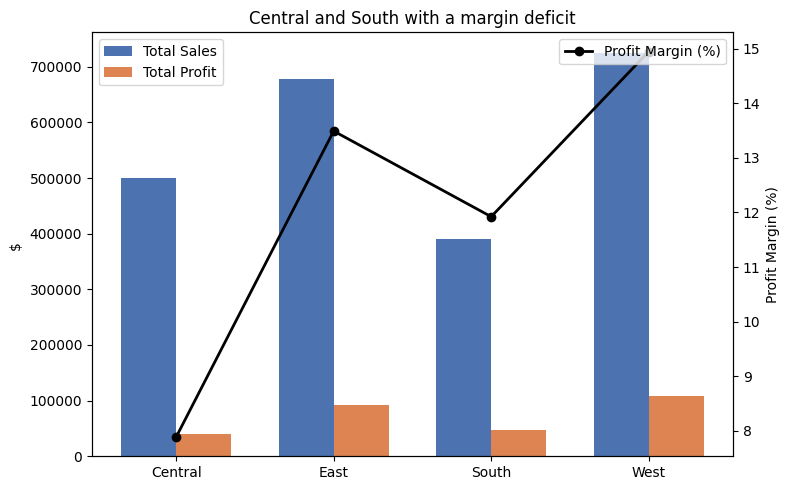

In [ ]:
region_summary = df1.groupby('Region').agg(
    total_sales=('Sales', 'sum'),
    total_profit=('Profit', 'sum'),
    total_orders=('Order ID', 'nunique'),
    avg_discount=('Discount', 'mean')
).reset_index()

region_summary['profit_margin'] = region_summary['total_profit'] / region_summary['total_sales'] * 100

# Representation
fig, ax1 = plt.subplots(figsize=(8, 5))

x = np.arange(len(region_summary))
width = 0.35

ax1.bar(x - width/2, region_summary['total_sales'], width, label='Total Sales', color='#4C72B0')
ax1.bar(x + width/2, region_summary['total_profit'], width, label='Total Profit', color='#DD8452')
ax1.set_ylabel('$ ')
ax1.set_xticks(x)
ax1.set_xticklabels(region_summary['Region'])
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(x, region_summary['profit_margin'], color='black', marker='o', linewidth=2, label='Profit Margin (%)')
ax2.set_ylabel('Profit Margin (%)')
ax2.legend(loc='upper right')

plt.title('Central and South with a margin deficit')
plt.tight_layout()
plt.show()

The West concentrates the company's strongest performance: highest sales, highest profit, lowest average discount, and a profit margin roughly double that of Central.

### 6.2. Pattern between category and region

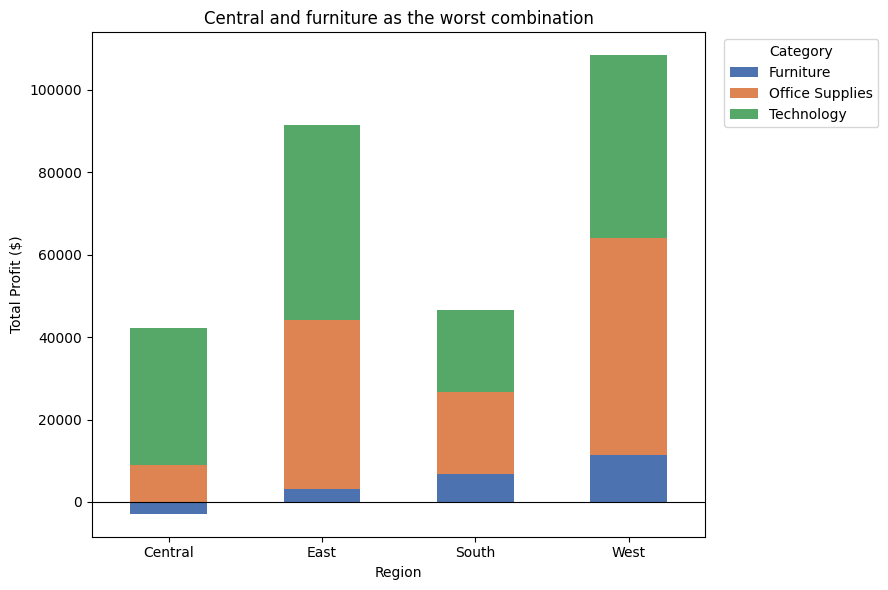

In [ ]:
region_cat = df1.groupby(['Region', 'Category'])['Profit'].sum().unstack()

region_cat.plot(kind='bar', stacked=True, figsize=(9, 6),color=['#4C72B0', '#DD8452', '#55A868'])

plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Total Profit ($)')
plt.xlabel('Region')
plt.title('Central and furniture as the worst combination')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Central consistently loses money in Furniture: a structural pattern, not a one-off 2017 event.

### 6.3. Is regional performance linked to delivery time?

In [ ]:
shipping_region = df1.groupby('Region')['Shipping_Time'].mean().sort_values()
shipping_region

,Shipping_Time
Region,
West,6.73
South,7.09
East,9.17
Central,14.63


Consider the logistical perspective to explain the financial implications of operations by region, as it is observed that the company takes up to fifteen days in central region (twice as long as in other regions) to ship its products

### 6.4 Does ship mode predict delivery time?

In [ ]:
# Kruskal-Wallis: does delivery time genuinely differ across the 4 shipping modes?
ship_modes = df1['Ship Mode'].unique()
groups_ship = [df1.loc[df1['Ship Mode'] == m, 'Shipping_Time'] for m in ship_modes]
h_stat, p_value = stats.kruskal(*groups_ship)
print(f"Kruskal-Wallis H = {h_stat:.2f}, "
      f"p-value {'< 0.001' if p_value < 0.001 else f'= {p_value:.4g}'}")

# If significant, locate exactly which modes differ from which
if p_value < 0.05:
    n_comparisons = len(list(combinations(ship_modes, 2)))
    alpha_corrected = 0.05 / n_comparisons
    print(f"\nPairwise comparisons (Bonferroni-corrected alpha = {alpha_corrected:.4f}):")
    for m1, m2 in combinations(ship_modes, 2):
        g1 = df1.loc[df1['Ship Mode'] == m1, 'Shipping_Time']
        g2 = df1.loc[df1['Ship Mode'] == m2, 'Shipping_Time']
        u_stat, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        flag = '  <-- significant' if p < alpha_corrected else ''
        print(f"{m1} vs {m2}: p = {p:.4f}{flag}")

Kruskal-Wallis H = 838.55, p-value < 0.001

Pairwise comparisons (Bonferroni-corrected alpha = 0.0083):
Second Class vs Standard Class: p = 0.0000  <-- significant
Second Class vs First Class: p = 0.0000  <-- significant
Second Class vs Same Day: p = 0.0000  <-- significant
Standard Class vs First Class: p = 0.0000  <-- significant
Standard Class vs Same Day: p = 0.0000  <-- significant
First Class vs Same Day: p = 0.0000  <-- significant


It is confirmed that delivery time differs significantly across all four shipping modes. The shipping system is well-designed and faithfully reflected in the data: there's no evidence that any two modes (e.g. Second Class and Standard Class) behave the same in practice despite carrying different labels.

<a name="customer"></a>
## 7. Customer Analysis

### 7.1 Customer Concentration by Region

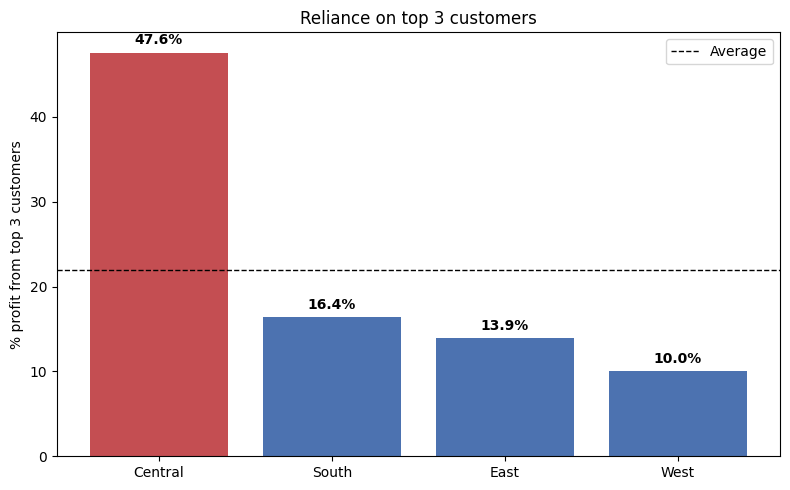

In [ ]:
top_customers_region = df1.groupby(['Region','Customer Name'])['Profit'].sum().reset_index()
top_customers_region = top_customers_region.sort_values('Profit', ascending=False).groupby('Region').head(3)
top3_by_region = top_customers_region.groupby('Region')['Profit'].sum()
total_by_region = df1.groupby('Region')['Profit'].sum()
concentration = (top3_by_region / total_by_region *100).round(1)

concentration_sorted = concentration.sort_values(ascending=False)

colors = ['#C44E52' if v == concentration_sorted.max() else '#4C72B0' for v in concentration_sorted]

plt.figure(figsize=(8, 5))
plt.bar(concentration_sorted.index, concentration_sorted.values, color=colors)
plt.axhline(concentration.mean(), color='black', linestyle='--', linewidth=1, label='Average')
plt.ylabel('% profit from top 3 customers')
plt.title('Reliance on top 3 customers')
plt.legend()

for i, v in enumerate(concentration_sorted.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
top3_central = ['Tamara Chand', 'Adrian Barton', 'Sanjit Chand']

evolution_furniture = df1[(df1['Customer Name'].isin(top3_central)) & (df1['Category'] == 'Furniture')].groupby(['Order Year', 'Customer Name'])['Profit'].sum().unstack()
evolution_furniture

Customer Name,Adrian Barton,Sanjit Chand
Order Year,,
2014,NaN,-68.39
2015,-84.45,22.01
2016,-204.45,142.63
2017,213.69,NaN


In [ ]:
central_customers = df1[df1['Region'] == 'Central']['Customer Name'].nunique()
pct_top3_central = 3 / central_customers * 100
print(f"Central has {central_customers} unique customers")
print(f"The top 3 represent {pct_top3_central:.1f}% of Central's customer base")

Central has 629 unique customers
The top 3 represent 0.5% of Central's customer base


Central shows the highest customer concentration in the dataset: its top 3 customers (just 0.5% of its customer base) account for 47.6% of total regional profit which is more than double the concentration seen in any other region.
This structural fragility helps explain why Central was also the most volatile region, recording the sharpest profit decline (-62.95%) in 2017. While that specific drop was driven by underperformance in the bookcases subcategory rather than customer churn, the region's heavy reliance on a small customer base remains a latent risk worth monitoring

Full business implications are consolidated in the Executive Summary.

### 7.2 Pareto Analysis

In [ ]:
# Step 1: Profit per customer
customer_revenue = df1.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

# Step 2: Cumulative share of profit
total_revenue = customer_revenue.sum()
cumulative_pct = customer_revenue.cumsum() / total_revenue * 100

# Step 3: Share of customers needed to reach 80% of profit
customers_for_80pct = (cumulative_pct <= 80).sum()
pct_customers = customers_for_80pct / len(customer_revenue) * 100
print(f"{pct_customers:.1f}% of customers generate 80% of profit")

# Step 4: Profit generated by the top 20% of customers
top_20_count = int(len(customer_revenue) * 0.2)
top_20_revenue = customer_revenue.head(top_20_count).sum()
top_20_pct = top_20_revenue / total_revenue * 100
print(f"Top 20% of customers generate {top_20_pct:.1f}% of profit")

19.0% of customers generate 80% of profit
Top 20% of customers generate 81.5% of profit


A textbook pareto pattern: **20% of customers generate 80% of profit**.

This dependency on a relatively small group of highly profitable customers is present company-wide, although reaching an extreme in the central region.

### 7.3 RFM Segmentation

In [ ]:
snapshot_date = df1['Order Date'].max() + pd.Timedelta(days=1)

rfm = df1.groupby('Customer Name').agg(
    recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    frequency=('Order ID', 'nunique'),
    monetary_sales=('Sales', 'sum'),
    monetary_profit=('Profit', 'sum')
).reset_index()

rfm.head()

,Customer Name,recency,frequency,monetary_sales,monetary_profit
0,Aaron Bergman,446,3,886.16,129.35
1,Aaron Hawkins,13,7,"1,744.70",365.22
2,Aaron Smayling,266,7,"3,050.69",-253.57
3,Adam Bellavance,106,8,"7,755.62","2,054.59"
4,Adam Hart,35,10,"3,250.34",281.19


In [ ]:
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])  # lower recency = better = 4
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['monetary_profit'], 4, labels=[1, 2, 3, 4])
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm['M_score_sales'] = pd.qcut(rfm['monetary_sales'], 4, labels=[1, 2, 3, 4])

# "Trap" customers: high in Sales (buy a lot) but low in Profit (leave little to no margin)
trap_customers = rfm[(rfm['M_score_sales'].astype(int) >= 3) & (rfm['M_score'].astype(int) <= 2)]
print(f"Number of 'trap' customers: {len(trap_customers)} of {len(rfm)} "
      f"({len(trap_customers) / len(rfm) * 100:.1f}%)")
trap_customers.sort_values('monetary_sales', ascending=False)

Number of 'trap' customers: 111 of 793 (14.0%)


,Customer Name,recency,frequency,monetary_sales,monetary_profit,R_score,F_score,M_score,RFM_Score,M_score_sales
686,Sean Miller,21,5,"25,043.05","-1,980.74",4,2,1,421,4
75,Becky Martin,308,4,"11,789.63","-1,659.96",1,1,1,111,4
307,Grant Thornton,264,3,"9,351.21","-4,108.66",1,1,1,111,4
606,Peter Fuller,836,4,"9,062.86",-614.29,1,1,1,111,4
557,Natalie Fritzler,21,7,"8,322.83","-1,695.97",4,3,1,431,4
...,...,...,...,...,...,...,...,...,...,...
510,Maureen Gastineau,93,4,"2,350.19",25.89,3,1,1,311,3
212,Dean Braden,10,10,"2,332.58",169.97,4,4,2,442,3
525,Michael Kennedy,140,8,"2,302.37",-405.36,2,4,1,241,3
176,Craig Carreira,196,7,"2,269.70",187.84,2,3,2,232,3


In [ ]:
def segment_customer(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif f >= 3 and m <= 2:
        return 'High activity, low profit'   # the "trap" segment
    elif r <= 2 and m >= 3:
        return 'At risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost / Low value'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

,count
Segment,
At risk,178
Regular,164
Lost / Low value,162
Champions,152
"High activity, low profit",137


In [ ]:
segment_summary = rfm.groupby('Segment').agg(
    n_customers=('Customer Name', 'count'),
    avg_profit=('monetary_profit', 'mean'),
    avg_sales=('monetary_sales', 'mean'),
    avg_frequency=('frequency', 'mean')
).reset_index()

segment_summary.sort_values('avg_profit', ascending=False)

,Segment,n_customers,avg_profit,avg_sales,avg_frequency
1,Champions,152,842.94,"4,338.94",8.51
0,At risk,178,802.66,"3,794.95",6.66
4,Regular,164,335.89,"2,173.70",4.54
3,Lost / Low value,162,-87.40,"1,392.37",3.93
2,"High activity, low profit",137,-189.24,"2,758.55",8.39


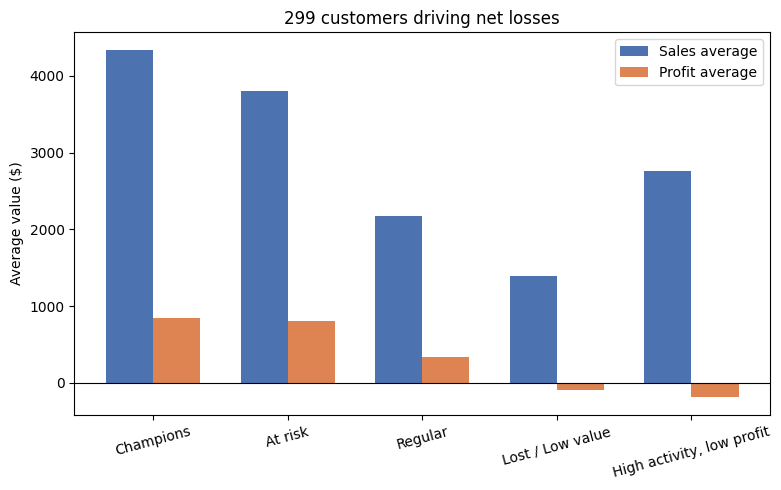

In [ ]:
segment_summary_sorted = segment_summary.sort_values('avg_profit', ascending=False)

x = np.arange(len(segment_summary_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, segment_summary_sorted['avg_sales'], width, label='Sales average', color='#4C72B0')
ax.bar(x + width/2, segment_summary_sorted['avg_profit'], width, label='Profit average', color='#DD8452')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(segment_summary_sorted['Segment'], rotation=15)
ax.set_ylabel('Average value ($)')
ax.set_title('299 customers driving net losses')
ax.legend()

plt.tight_layout()
plt.show()

Segmenting customers via RFM with Profit as the monetary dimension reveals a blind spot: 137 customers (17% of the customer base) fall into a 'High activity, low profit' segment. They buy almost as often as Champions, yet generating a negative average profit of $189.

<a name="discount-policy"></a>
## 8. Discount Policy & Structural Loss by Price Tier

In [ ]:
# Share of orders with a loss, by sub-category and discount band
df1['Discount_Band'] = pd.cut(df1['Discount'],bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.50, 1],labels=['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%'])

loss_analysis = df1.groupby(['Sub-Category', 'Discount_Band']).apply(
    lambda x: (x['Profit'] < 0).mean() * 100
).reset_index(name='pct_orders_with_loss')

loss_analysis.sort_values('pct_orders_with_loss', ascending=False)

/tmp/ipykernel_468/3210980115.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loss_analysis = df1.groupby(['Sub-Category', 'Discount_Band']).apply(
/tmp/ipykernel_468/3210980115.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  loss_analysis = df1.groupby(['Sub-Category', 'Discount_Band']).apply(


,Sub-Category,Discount_Band,pct_orders_with_loss
15,Bookcases,>50%,100.00
10,Binders,>50%,100.00
5,Appliances,>50%,100.00
14,Bookcases,31-50%,100.00
50,Tables,31-50%,100.00
37,Machines,>50%,100.00
29,Furnishings,>50%,100.00
19,Chairs,21-30%,93.63
49,Tables,21-30%,92.59
13,Bookcases,21-30%,90.00


In [ ]:
# Average unit price by sub-category
avg_price = df1.groupby('Sub-Category').apply(
    lambda x: (x['Sales'] / x['Quantity']).mean()
).reset_index(name='avg_unit_price')

avg_price.sort_values('avg_unit_price', ascending=False)

/tmp/ipykernel_468/1999676271.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_price = df1.groupby('Sub-Category').apply(


,Sub-Category,avg_unit_price
6,Copiers,601.02
11,Machines,423.35
16,Tables,165.09
5,Chairs,138.80
4,Bookcases,131.10
13,Phones,101.13
14,Storage,70.45
15,Supplies,69.31
1,Appliances,60.62
0,Accessories,55.31


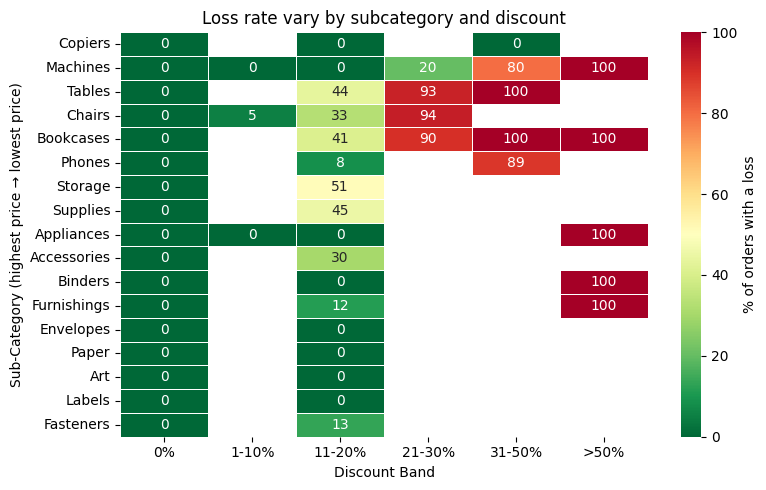

In [ ]:
loss_pivot = loss_analysis.pivot(index='Sub-Category', columns='Discount_Band', values='pct_orders_with_loss')

# Order columns logically
band_order = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%']
loss_pivot = loss_pivot[band_order]

# Order rows by average unit price (high to low), so price tier is visible top-to-bottom
price_order = avg_price.sort_values('avg_unit_price', ascending=False)['Sub-Category']
loss_pivot = loss_pivot.reindex(price_order)

plt.figure(figsize=(8, 5))
sns.heatmap(loss_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            cbar_kws={'label': '% of orders with a loss'}, linewidths=0.5)
plt.title('Loss rate vary by subcategory and discount')
plt.xlabel('Discount Band')
plt.ylabel('Sub-Category (highest price → lowest price)')
plt.tight_layout()
plt.show()

The discount threshold at which losses become dominant is not fixed at 20% across the board. It depends on product price tier. High-priced subcategories (Machines, Bookcases, Tables) already show majority losses above 10-11% discount, while lower-priced ones sustain discounts up to 20-30%.

<a name="order-level"></a>
## 9. Order-Level Profitability

In [ ]:
order_profit = df1.groupby('Order ID').agg(Order_Sales=('Sales', 'sum'), Order_Profit=('Profit', 'sum')).reset_index()

order_profit['Order Profit Margin'] = order_profit['Order_Profit'] / order_profit['Order_Sales']
df1 = df1.merge(order_profit[['Order ID', 'Order Profit Margin']], on='Order ID', how='left')

order_profit.sort_values('Order Profit Margin', ascending=True)

,Order ID,Order_Sales,Order_Profit,Order Profit Margin
4952,US-2017-155299,1.62,-4.47,-2.75
4101,CA-2017-165099,1.39,-3.76,-2.70
3693,CA-2017-144680,33.62,-90.77,-2.70
4798,US-2017-116701,66.28,-178.97,-2.70
1635,CA-2015-164007,145.50,-392.86,-2.70
...,...,...,...,...
4066,CA-2017-163188,38.16,19.08,0.50
2980,CA-2017-108000,9.78,4.89,0.50
3003,CA-2017-109211,16.98,8.49,0.50
26,CA-2014-101833,34.44,17.22,0.50


In [ ]:
df1.groupby('Category')['Profit Margin'].mean().sort_values()
df1.groupby('Sub-Category')['Profit Margin'].mean().sort_values()

print('Products with the lowest average margin (candidates for price or discount review):')
df1.groupby('Product Name')['Profit Margin'].mean().sort_values().head(10)

Products with the lowest average margin (candidates for price or discount review):


,Profit Margin
Product Name,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,-2.75
"Bush Westfield Collection Bookcases, Dark Cherry Finish, Fully Assembled",-2.10
Euro Pro Shark Stick Mini Vacuum,-1.77
3.6 Cubic Foot Counter Height Office Refrigerator,-1.48
Okidata B401 Printer,-1.40
Zebra GK420t Direct Thermal/Thermal Transfer Printer,-1.33
Hoover Commercial Lightweight Upright Vacuum,-1.31
Kensington 6 Outlet SmartSocket Surge Protector,-1.25
Acco 6 Outlet Guardian Basic Surge Suppressor,-1.16


In [ ]:
print('Which categories can sustain deeper discounts?')
df1.groupby(['Category', 'Discount_Band'])['Profit Margin'].mean().unstack()

Which categories can sustain deeper discounts?


/tmp/ipykernel_691/1829009517.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby(['Category', 'Discount_Band'])['Profit Margin'].mean().unstack()


Discount_Band,0%,1-10%,11-20%,21-30%,31-50%,>50%
Category,,,,,,
Furniture,0.29,0.13,0.07,-0.12,-0.41,-0.78
Office Supplies,0.37,0.25,0.23,NaN,NaN,-1.22
Technology,0.29,0.33,0.11,0.11,-0.16,-1.05


The threshold at which profit margins turn negative varies significantly across categories: *furniture* within the 21-30% discount band; *technology* remains resilient longer, staying positive through the 21–30% band before dropping into negative margins at 31–50% and *office supplies* lacks sufficient data points in these intermediate discount brackets.

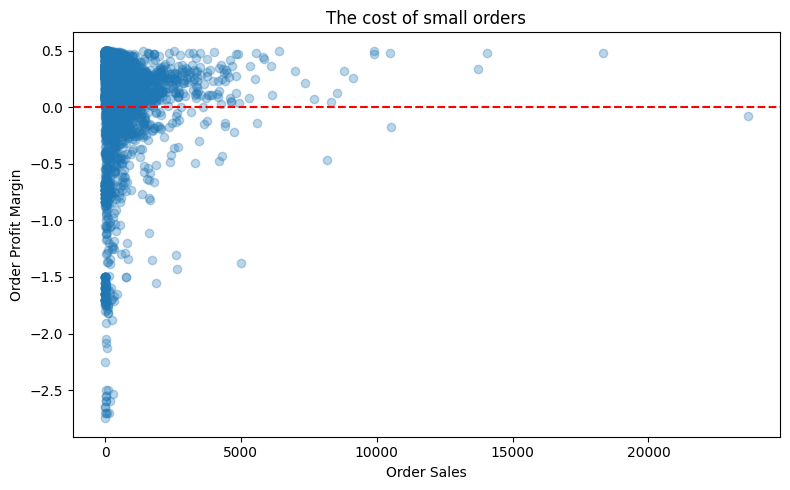

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(order_profit['Order_Sales'], order_profit['Order Profit Margin'], alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Order Sales')
plt.ylabel('Order Profit Margin')
plt.title('The cost of small orders')
plt.tight_layout()
plt.show()

Small orders lead to the worst profit margins (down to -260/-275%). This is a ratio effect: a small dollar loss on a tiny order swings the percentage dramatically, while the same loss on a large order barely moves it. The table below checks this pattern against the actual dollar amounts.

In [ ]:
# Most and least efficient orders by margin
most_efficient = order_profit.sort_values('Order Profit Margin', ascending=False).head(10)
least_efficient = order_profit.sort_values('Order Profit Margin', ascending=True).head(10)
least_efficient

,Order ID,Order_Sales,Order_Profit,Order Profit Margin
4952,US-2017-155299,1.62,-4.47,-2.75
4101,CA-2017-165099,1.39,-3.76,-2.70
3693,CA-2017-144680,33.62,-90.77,-2.70
4798,US-2017-116701,66.28,-178.97,-2.70
1635,CA-2015-164007,145.50,-392.86,-2.70
4836,US-2017-124926,9.32,-24.71,-2.65
15,CA-2014-101147,2.39,-6.34,-2.65
373,CA-2014-130421,176.77,-459.61,-2.60
1060,CA-2015-120397,32.78,-85.24,-2.60
2805,CA-2017-100356,23.99,-62.38,-2.60


Cross-checking against absolute profit shows a mixed picture. Several of the worst-margin orders are indeed tiny ($ 1.39-9.32 in sales, 3.76-24.71 in losses) which is exactly the ratio distortion described above. But others are not: order CA-2015-164007 (145.50 in sales) lost 392.86, and CA-2014-130421 (176.77 in sales) lost 459.61.

In big orders, that low profit is due to the discount.

<a name="executive-summary"></a>
## 10. Executive Summary & Business Recommendations

This analysis goes beyond descriptive EDA: every major finding below was either statistically validated or checked against a competing explanation before being turned into a recommendation.


- **Discounting has a statistically confirmed threshold and it depends on price tier.** Average profit margin swings from **+26.7% to -91.5%** between orders discounted ≤20% and those discounted >30%. It is not a visual impression but a validated effect. That threshold isn't uniform: high-priced sub-categories (machines, bookcases, tables) turn structurally unprofitable above just 10-11% discount, while lower-priced items tolerate 20-30%.

| **Recommendation:** replace the single blanket discount cap with a tiered policy by product price range, with furniture capped well before the 40% mark.

- **The steepest profit drop in the dataset (April 2017) was a localized and product-driven event. Not a business downturn.** It's concentrated in furniture (mainly bookcases) within central and south regions, while east and west grew over the same period. It isn't linked to heavier discounting.

|**Recommendation:** focused on bookcases cost structure and regional pricing in Central/South specifically, rather than adjusting company-wide discount policy for a problem that isn't company-wide.

- **Central is the most structurally fragile region on three independent dimensions at once.** It has the lowest profit margin, the highest customer concentration (top 3 customers = 47.6% of regional profit from just 0.5% of its customer base) and shipping times roughly double every other region (up to 15 days). Critically, this isn't a shipping mode artifact meaning Central's delay is a genuine regional logistics problem, not customers there simply choosing slower delivery options.

|**Recommendation:** treat central as a priority for account-retention safeguards and a logistics audit.

- **Profitability is heavily concentrated in a small share of customers.** Just 19% of customers account for 80% of total profit. On top of that, **137 customers** (17% of the customer base) buys almost as often as top customers, yet averages **-$189 in profit each**.

|**Recommendation:** The small and high-profit customer base must be protected with retention efforts. For the non-profitable group: return fees applied to customers with unusually high return rates, minimum purchase limits or bundled products

- **An extreme profit margin means two very different things depending on order size.** In small orders, margins of 275% are a statistical artifact: 3 to 25 dollars loss on an order worth just a few dollars inflates the percentage dramatically, even though the real dollar impact is trivial. In mid-sized orders, the *same* extreme margin is a genuine business problem: CA-2015-164007 ($145.50 in sales) lost 392.86, and CA-2014-130421 (176.77 dollars in sales) lost 459.61, both driven by deep discounting, not order size.

|**Recommendation:** split any margin-based alert by order size. Small order extreme margins can be ignored, while mid/large-order extreme margins should be flagged as priority cases for discount-policy review.